<img style="float: left;" src="Lecture_eng/Slide2.PNG" width="100%">

<img style="float: left;" src="Lecture_eng/Slide3.PNG" width="100%">

## <span style="color:red">Exercise 1:  Compressibility graph</span>

#### Plot graph of compressibility Z vs. normal pressure for:
 * Pure methane
 * Mixture of methane (85%), nitrogen (10%) and carbon dioxide (5%)
#### at 3 temperatures T = 30, 60 and 90 C

In [1]:
import numpy as np

# procedure returning critical properties for several components
def props(component, params):
    properties = [["C1",    "CO2",   "N2",    "H2S",   "C2",    "H2"],      # component
                  [190.58,  304.10,  126.20,  373.53,  305.32,  33.0],      # T_c [K]
                  [46.04,   73.75,   34.00,   89.63,   48.72,   13.0],      # p_c [bar]
                  [16.043,  44.01,   28.013,  34.076,  30.07,   2.02]]      # molecular mass [g/mol]
                                                             
    name = ["Tc", "Pc", "Mw"]
    index1 = name.index(params) + 1
    index2 = properties[0][:].index(component)
    c = properties[index1][index2]

    return c

# procedure returning binary  for several components
def binary(component, components):
    # binary interaction parameters for CH4, CO2 ...    
    # binary interaction parameters for CH4, CO2 ...    
    dij = [["CO2",    "C1",      "N2",   "H2S",   "C2",  "H2"],  
           [ 0,       0.100,  -0.017,   0.0974,   0.1,   0.1 ],
           [ 0.100,   0,       0.0311,  0.0503,   0,    -0.1 ],
           [-0.017,   0.0311,  0,       0.1767,   0.1,   0.14],
           [ 0.0974,  0.0503,  0.1767,  0,        0.05,  0.02],
           [ 0.1,     0,       0.1,     0.05,     0,     0.01],
           [ 0.1,    -0.1,     0.14,    0.02,     0.0,   0   ]]  

    d = []
    index1 = dij[0].index(component) + 1
    for c in components:
        index2 = dij[0].index(c)
        d.append(dij[index1][index2])
        
    return d


# compute Z based on van der Waals EoS
def vapour_compress(R, p, T, x, components):
    NC = np.size(x)

    b = 0
    ai = np.zeros(NC)
    for i in range(NC):
        Tc = props(components[i], "Tc")
        Pc = props(components[i], "Pc")
        ai[i] = (0.4219 * R ** 2 * Tc ** 2) / Pc
        b += x[i] * (0.125 * R * Tc) / Pc

    a = 0
    for i in range(NC):
        d = binary(components[i], components)
        for j in range(NC):            
            aij = (1 - d[j]) * (ai[i] ** 0.5) * (ai[j] ** 0.5)
            a +=  x[i] * x[j] * aij

    A = - ((R * T / p) + b)
    B = a / p
    C = - (a * b) / p

    # solve cubic equations with corresponding coefficient 
    V = np.roots([1, A, B, C])  # 3 real roots: take max
    
    if np.sum(np.isreal(V)) == 3:
        V_out = np.amax(V)          # Z is max root out of 3
    else:
        index = np.isreal(V)
        V_out = np.real(V[index])   # Z is the only real root
        
    Z_out = (p * V_out) / (R * T)

    return Z_out

## <span style="color:red">Excersise 2: Compute pressure changes</span>

#### Consider gas production from reservoir contained mixture from Exercise 1:
 * Area of reservoir: 1 by 1 km 
 * Tickness of reservoir: 80 m
 * Initial pressure: 200 bars
 * Porosity: 20%
 * Rock compressibility: $10^{-5}$ 1/bar
 
#### Compute pressure in the reservoir after 20 years of production with the yearly rate $10^8$ m$^3$

In [2]:
rock_compr = 1e-5
comp = ['C1', 'N2', 'CO2']
y = [.85, .10, .05]

def calculate_rho_gas(p, temp, comp, y):
    R = 8.1345e-2 # J/K/mol
    masses = np.array([16.043, 28.013, 44.01])
    M = np.sum(masses * y)
    
    Z_p = vapour_compress(R, p, temp, y, comp)
    #Z_p = (p * volume) / (R * temp)
    rho_gas = (M * p) / (Z_p * R * temp)
    
    return rho_gas
   
def calculate_poro(p):
    
    phi_0 = 0.2
    phi = phi_0 * (1 + rock_compr * (p - p_0))

    return phi

def calculate_dphi_drho(p, t, comp, y):
    dp = 1e-4
    
    pplusdp = calculate_poro(p-dp) * calculate_rho_gas(p-dp, t, comp, y)
    psingle = calculate_poro(p) * calculate_rho_gas(p, t, comp, y)

    dphi_drho = (1 / dp) * (pplusdp - psingle)
    return dphi_drho

C:\Users\lange\anaconda3\lib\site-packages\numpy\core\shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


[66.5661775]


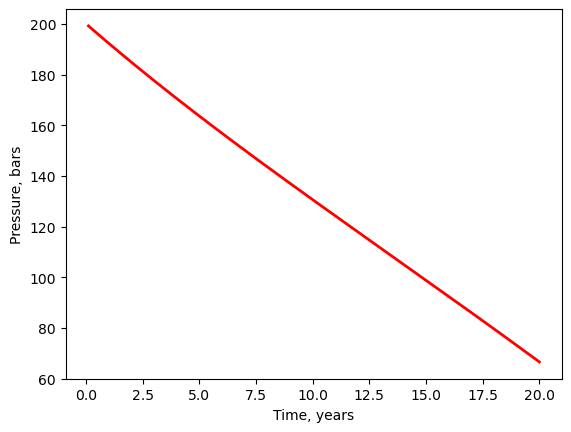

In [3]:
from matplotlib import pyplot as plt

p_0 = 200 # bar
temp_sc = 288

temp = temp_sc + 60

X = 1000
Y = 1000
h = 80

volume = X*Y*h
gas_extracted_surf = 100e6

year = 0
p_vec = []
t_vec = []
p = p_0

dt = 0.1

gas_extracted_mass = dt * gas_extracted_surf * calculate_rho_gas(1, temp_sc, comp, y)

for year in np.arange(0, 20, dt):
    
    pn = p +  gas_extracted_mass / volume / calculate_dphi_drho(p, temp, comp, y)
    
    year += dt
    t_vec.append(year)
    p_vec.append(pn)
    p = pn
    
print(p)

plt.plot(t_vec, p_vec, 'red', linewidth=2)
plt.xlabel('Time, years')
plt.ylabel('Pressure, bars')
plt.show()

<img style="float: left;" src="Lecture_eng/Slide4.PNG" width="100%">

<img style="float: left;" src="Lecture_eng/Slide5.PNG" width="100%">

## <span style="color:red">Exercise 3: Account for subsidence </span>

#### Consider gas production from reservoir contained mixture from the Exercise 2 

[66.47627614] [0.10681898]


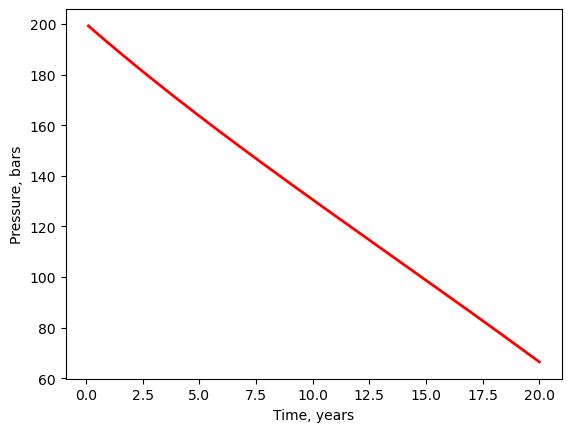

In [4]:
water_fraction = 0.0

subsidence = 0
year = 0
p_vec = []
t_vec = []
p = p_0

dt = 0.1

gas_extracted_mass = dt * gas_extracted_surf * calculate_rho_gas(1, temp_sc, comp, y)

for year in np.arange(0, 20, dt):

    pn = p + gas_extracted_mass / volume / calculate_dphi_drho(p, temp, comp, y)

    subsidence += (p - pn) * rock_compr * h
    volume = X*Y*(h-subsidence)

    year += dt
    t_vec.append(year)
    p_vec.append(pn)
    p = pn
    
print(p, subsidence)

plt.plot(t_vec, p_vec, 'red', linewidth=2)
plt.xlabel('Time, years')
plt.ylabel('Pressure, bars')
plt.show()